<a href="https://colab.research.google.com/github/ThomasAlbin/Space-Science-With-Python/blob/main/2026/exoplanets_habitable_zone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fetching Exoplanet Data

This notebook fetches exoplanet data from the NASA Exoplanet Archive, filters for potentially habitable candidates based on radius and equilibrium temperature, and visualizes them alongside all scanned planets.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Download the Data

This script utilizes the NASA Exoplanet Archive's TAP (Table Access Protocol) API to download exoplanet data. It constructs a URL to query for planet names, radii, orbital periods, and equilibrium temperatures, specifically for default entries in the archive. The data is then downloaded as a CSV file and loaded into a pandas DataFrame.

The base URL for the API is `https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=`.
The query string used is `select pl_name,pl_rade,pl_orbper,pl_eqt from ps where default_flag=1&format=csv`, which selects the specified columns for planets marked with a default flag and formats the output as CSV.

In [ ]:
# We use the NASA Exoplanet Archive TAP (Table Access Protocol) API.
# Query: Select Name, Radius, Period, and Temperature for all "default" planet entries.
base_url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query="
query = "select+pl_name,pl_rade,pl_orbper,pl_eqt+from+ps+where+default_flag=1&format=csv"
full_url = base_url + query

print("Downloading data from NASA... (this may take a few seconds)")
df = pd.read_csv(full_url)

In [ ]:
df

,pl_name,pl_rade,pl_orbper,pl_eqt
0,HR 8799 d,13.000000,37000.000000,NaN
1,WASP-96 b,13.450000,3.425260,1285.0
2,HD 114783 b,NaN,493.700000,NaN
3,HAT-P-1 b,14.784671,4.465300,1322.0
4,HR 8799 b,13.000000,170000.000000,NaN
...,...,...,...,...
6060,GJ 357 d,NaN,55.661000,219.6
6061,K2-138 c,2.299000,3.560040,NaN
6062,WASP-71 b,13.226620,2.903670,NaN
6063,TOI-1648 b,2.540000,7.331602,799.0


## Drop Missing Data

This step filters out any planet entries from the DataFrame that have missing values in either the 'pl_rade' (planet radius) or 'pl_eqt' (equilibrium temperature) columns. These specific columns are crucial for identifying potentially habitable candidates, so rows with incomplete data for them are removed to ensure the subsequent analysis is based on robust information.

In [ ]:
# Filter out planets with missing temperature or radius data
df = df.dropna(subset=['pl_rade', 'pl_eqt'])

## The Definition of "Earth-Like"

For the purposes of this analysis, we define "Earth-like" planets based on simplified approximations for their radius and equilibrium temperature. While scientists continuously debate the precise boundaries, these criteria provide a working definition for identifying potentially habitable candidates:

*   **Radius:** Between 0.8 and 1.5 Earth Radii (This range suggests a likely rocky composition, similar to Earth).
*   **Equilibrium Temperature:** Between 200K (-73°C) and 320K (47°C) (This temperature range indicates the potential for liquid water to exist on the planet's surface).

It's important to note that these are simplifications for illustration and may not encompass all factors contributing to true habitability.

In [ ]:
# Scientists argue about these numbers, but for our short video,
# these are "solid" approximations:
# Radius: Between 0.8 and 1.5 Earth Radii (likely rocky)
# Temp: Between 200K (-73C) and 320K (47C) (Equilibrium temp, water might exist)
habitable_planets = df[
    (df['pl_rade'] > 0.8) & (df['pl_rade'] < 1.5) &
    (df['pl_eqt'] > 200) & (df['pl_eqt'] < 320)
]

print(f"Total Planets Scanned: {len(df)}")
print(f"Potentially Habitable Candidates Found: {len(habitable_planets)}")
print(habitable_planets['pl_name'].head()) # Show top 5 names

Total Planets Scanned: 1482
Potentially Habitable Candidates Found: 8
1215           K2-3 d
1874    Kepler-1649 c
3166    Kepler-1126 c
3411       TOI-2095 c
5116       LP 890-9 c
Name: pl_name, dtype: object


## Visualisation of the data

Finally, we visualize the data along the Earth. Can you see an observation bias in the data?

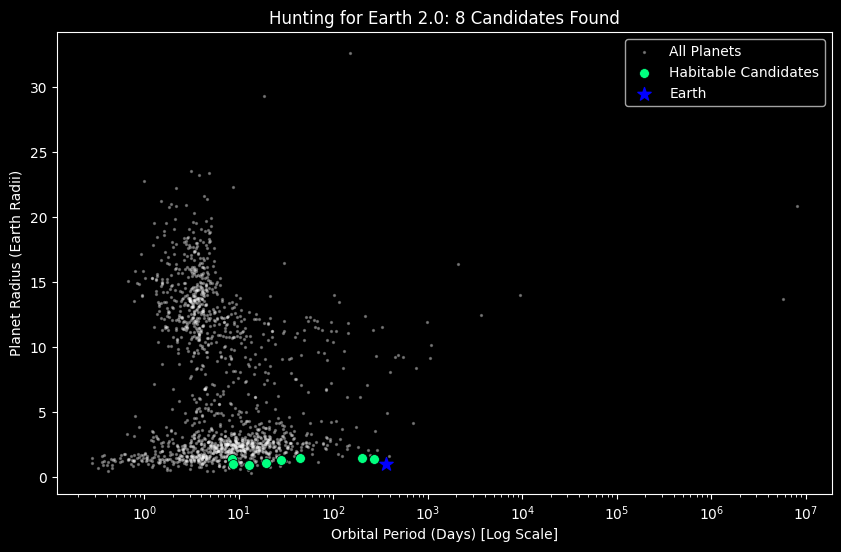

In [ ]:
plt.figure(figsize=(10, 6))
plt.style.use('dark_background') # Apply dark mode style

# Get current axes
ax = plt.gca()

# Plot ALL planets in a light color (The "Haystack")
plt.scatter(
    df['pl_orbper'],
    df['pl_rade'],
    color='white',
    alpha=0.3,
    s=2,
    label='All Planets'
)

# Plot HABITABLE candidates in Green (The "Needles")
plt.scatter(
    habitable_planets['pl_orbper'],
    habitable_planets['pl_rade'],
    color='springgreen',
    s=50,
    label='Habitable Candidates',
    edgecolor='black',
    linewidth=0.5
)

# Highlight Earth for context (1 Year Period, 1 Earth Radius)
plt.scatter(365, 1, color='blue', s=100, marker='*', label='Earth')

# Formatting for the "Science" look
plt.xscale('log') # Log scale because periods range from days to centuries
plt.xlabel('Orbital Period (Days) [Log Scale]', color='white')
plt.ylabel('Planet Radius (Earth Radii)', color='white')
plt.title(f'Hunting for Earth 2.0: {len(habitable_planets)} Candidates Found', color='white')
plt.legend()

# Set axis tick parameters and spine colors to white
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.spines['bottom'].set_color('white')
ax.spines['top'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['right'].set_color('white')

plt.show()